# Matrices de confusion y metricas por modelo

Evalua las predicciones de `IA/predicciones.csv`.

Importante: `potencial` y `dias` son modelos secuenciales. Por eso este notebook reconstruye la longitud de historial por `Id. Cliente` + `Id. Producto` y evalua esos modelos solo en filas con el `min_history` guardado en cada checkpoint.

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    root_mean_squared_error,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

BASE_DIR = Path.cwd().resolve()
IA_DIR = BASE_DIR.parent if BASE_DIR.name.lower() == "tests" else BASE_DIR

PREDICCIONES_PATH = IA_DIR / "predicciones.csv"
POTENCIAL_CHECKPOINT = IA_DIR / "models" / "potencial_model.pt"
DIAS_CHECKPOINT = IA_DIR / "models" / "dias_model.pt"

PREDICCIONES_PATH

WindowsPath('C:/Users/PE2554/Desktop/interhack/InterHack-2026/IA/predicciones.csv')

## Carga de datos y checkpoints

In [32]:
df = pd.read_csv(PREDICCIONES_PATH)
potencial_ckpt = torch.load(POTENCIAL_CHECKPOINT, map_location="cpu", weights_only=False)
dias_ckpt = torch.load(DIAS_CHECKPOINT, map_location="cpu", weights_only=False)

print(f"Filas: {len(df):,} | Columnas: {len(df.columns):,}")
display(df.head())

Filas: 156,921 | Columnas: 40


,Num.Fact,Fecha,Id. Cliente,Provincia,Id. Producto,Unidades,Valores_H,Bloque analítico,Categoria_H,Familia_H,tiempo_medio_recompra_dias,std_recompra_dias,dias_desde_compra_anterior_producto,tiempo_medio_entre_compras_dias,std_entre_compras_dias,zscore_momento_cliente_producto,zscore_momento_recompra_general,n_anios_cliente_categoria,gasto_medio_anual_cliente_categoria_producto,gasto_medio_anual_cliente_categoria,peso_producto_en_categoria,gasto_anual_real_cliente_producto,numero_compras_anteriores_producto,total_compras_cliente_otros_productos,numero_devoluciones_producto,vuelve_a_comprar,dias_hasta_proxima_compra,target_potencial_cliente,gasto_base_anual_fidelizacion,gasto_futuro_anual_fidelizacion,frecuencia_base_anual_fidelizacion,frecuencia_futura_anual_fidelizacion,score_riesgo_0_100,score_potencial_0_100,potencial_clase_predicha,prediccion_dias_hasta_proxima_compra,prediccion_fecha_proxima_compra,prediccion_mes_proxima_compra,prediccion_dia_proxima_compra,prediccion_bucket_mes_modelo_dias
0,3910002518,2024-01-04,1818,Las Palmas,3408,4,284.6724,Commodities,Categoria C1,Familia C1,184.320516,165.241975,169.0,134.636364,67.036218,0.512613,-0.092716,5.0,556.19448,1187.77408,0.468266,818.4096,7,20,0,1,98,0.318947,496.0572,533.7372,2.0,3.0,5.299342,61.893517,positivo,102.7,2024-04-16,2024-04,16,mes_03
1,3910002518,2024-01-04,1818,Las Palmas,4565,1,114.6728,Commodities,Categoria C1,Familia C1,173.383726,161.061119,169.0,212.000000,84.184322,-0.510784,-0.027218,5.0,101.58528,1187.77408,0.085526,114.6728,3,28,0,0,1500,-1.000000,370.1432,0.0000,3.0,0.0,74.158930,1.610217,muy_negativo,217.0,2024-08-08,2024-08,8,mes_11
2,3910002518,2024-01-04,1818,Las Palmas,4567,1,146.5752,Commodities,Categoria C1,Familia C1,299.145040,280.055722,169.0,98.733333,47.720117,1.472475,-0.464711,5.0,529.99432,1187.77408,0.446208,696.2322,11,16,0,1,98,0.222987,466.6982,549.6570,3.0,3.0,6.753415,70.498000,positivo,83.9,2024-03-28,2024-03,28,mes_02
3,3910002519,2024-01-04,5787,Las Palmas,5099,1,335.9172,Productos Técnicos,Categoria T1,Familia T1,108.254921,145.801652,183.0,94.578947,53.799335,1.643534,0.512649,5.0,2011.87964,2688.64384,0.748288,2922.4922,9,6,0,1,83,0.574717,1587.3328,2586.5750,3.0,5.0,4.974103,94.712190,muy_positivo,54.4,2024-02-27,2024-02,27,mes_01
4,3910002520,2024-01-04,1000080471,Las Palmas,3408,6,384.3046,Commodities,Categoria C1,Familia C1,184.320516,165.241975,91.0,145.600000,63.505380,-0.859770,-0.564751,5.0,792.14664,1531.66688,0.517179,1451.7790,7,16,0,1,76,-0.059616,1265.0746,1067.4744,4.0,2.0,5.025601,44.381027,estable,95.5,2024-04-09,2024-04,9,mes_02


In [33]:
POTENCIAL_CLASS_NAMES = potencial_ckpt.get(
    "potencial_class_names",
    ["muy_negativo", "negativo", "estable", "positivo", "muy_positivo"],
)
POTENCIAL_BINS = [-1.01, -0.5, -0.1, 0.1, 0.5, 1.01]

MAX_SEQ_LEN_POTENCIAL = int(potencial_ckpt.get("max_seq_len", 12))
MIN_HISTORY_POTENCIAL = int(potencial_ckpt.get("min_history", 1))
MAX_SEQ_LEN_DIAS = int(dias_ckpt.get("max_seq_len", 12))
MIN_HISTORY_DIAS = int(dias_ckpt.get("min_history", 1))

# Por defecto se evalua el split de test reconstruido como en entrenamiento.
# Cambia a "all" si quieres evaluar todas las predicciones de predicciones.csv.
EVAL_SCOPE = "test"
RANDOM_SEED = 42

# score_riesgo_0_100 alto indica riesgo de no recompra.
UMBRAL_RIESGO_RECOMPRA = 50

# Clases auxiliares reales del checkpoint de dias: mes_00, mes_01, ..., mes_12.
DIAS_BUCKET_LABELS = dias_ckpt.get("aux_class_names", [f"mes_{idx:02d}" for idx in range(13)])

config = {
    "potencial_max_seq_len": MAX_SEQ_LEN_POTENCIAL,
    "potencial_min_history": MIN_HISTORY_POTENCIAL,
    "dias_max_seq_len": MAX_SEQ_LEN_DIAS,
    "dias_min_history": MIN_HISTORY_DIAS,
    "dias_bucket_labels": DIAS_BUCKET_LABELS,
    "eval_scope": EVAL_SCOPE,
}
config

{'potencial_max_seq_len': 12,
 'potencial_min_history': 2,
 'dias_max_seq_len': 12,
 'dias_min_history': 2,
 'dias_bucket_labels': ['mes_00',
  'mes_01',
  'mes_02',
  'mes_03',
  'mes_04',
  'mes_05',
  'mes_06',
  'mes_07',
  'mes_08',
  'mes_09',
  'mes_10',
  'mes_11',
  'mes_12'],
 'eval_scope': 'test'}

## Utilidades

In [34]:
def plot_confusion(y_true, y_pred, labels, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    values = cm
    fmt = "d"
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        values = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        fmt = ".2%"

    plt.figure(figsize=(max(7, len(labels) * 1.15), max(5, len(labels) * 0.85)))
    sns.heatmap(
        values,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
    )
    plt.title(title)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(cm, index=pd.Index(labels, name="real"), columns=pd.Index(labels, name="pred"))


def classification_metrics(y_true, y_pred, labels, model_name):
    return pd.DataFrame([
        {
            "modelo": model_name,
            "n": len(y_true),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        }
    ])


def bucket_days(series):
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    bucket_idx = np.floor(np.clip(values, 0, None) / 30).astype("float")
    bucket_idx = np.clip(bucket_idx, 0, len(DIAS_BUCKET_LABELS) - 1)
    labels = pd.Series(pd.NA, index=series.index, dtype="string")
    valid = ~np.isnan(bucket_idx)
    labels.loc[valid] = [DIAS_BUCKET_LABELS[int(idx)] for idx in bucket_idx[valid]]
    return labels

## Secuencias y split de evaluacion

Se reconstruyen las secuencias como en entrenamiento. `potencial` usa todas las filas validas; `dias` usa solo filas con `vuelve_a_comprar == 1`, igual que `train_.py`.

In [35]:
def add_sequence_length(frame, out_col):
    seq = frame[["Id. Cliente", "Id. Producto", "Fecha", "Num.Fact", "__orig_index__"]].copy()
    seq["Fecha"] = pd.to_datetime(seq["Fecha"], errors="coerce")
    seq = seq.dropna(subset=["Fecha"])
    seq = seq.sort_values(["Id. Cliente", "Id. Producto", "Fecha", "Num.Fact", "__orig_index__"], kind="mergesort")
    seq[out_col] = seq.groupby(["Id. Cliente", "Id. Producto"]).cumcount() + 1
    return seq.set_index("__orig_index__")[out_col]


def build_end_samples(frame, min_history, target_col=None):
    samples = []
    ordered = frame.sort_values(["Id. Cliente", "Id. Producto", "Fecha", "Num.Fact", "__orig_index__"], kind="mergesort").reset_index(drop=True)
    for _, group in ordered.groupby(["Id. Cliente", "Id. Producto"], sort=False):
        if len(group) < min_history:
            continue
        for pos in range(min_history - 1, len(group)):
            row = group.iloc[pos]
            sample = {"orig_index": int(row["__orig_index__"]), "cut_date": row["Fecha"]}
            if target_col is not None:
                sample[target_col] = int(row[target_col])
            samples.append(sample)
    return samples


def split_random_test_indices(samples, seed=42, train_ratio=0.8, val_ratio=0.1):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(samples))
    rng.shuffle(indices)
    n_train = int(len(indices) * train_ratio)
    n_val = int(len(indices) * val_ratio)
    return {samples[idx]["orig_index"] for idx in indices[n_train + n_val:]}


def split_stratified_test_indices(samples, class_col, n_classes, seed=42, train_ratio=0.8, val_ratio=0.1):
    rng = np.random.default_rng(seed)
    test = set()
    for class_idx in range(n_classes):
        class_samples = [sample for sample in samples if sample[class_col] == class_idx]
        indices = np.arange(len(class_samples))
        rng.shuffle(indices)
        n_train = int(len(indices) * train_ratio)
        n_val = int(len(indices) * val_ratio)
        test.update(class_samples[idx]["orig_index"] for idx in indices[n_train + n_val:])
    return test


df["__orig_index__"] = np.arange(len(df), dtype=np.int64)

potencial_base = df.dropna(subset=["Fecha", "Id. Cliente", "Id. Producto", "target_potencial_cliente"]).copy()
potencial_base["Fecha"] = pd.to_datetime(potencial_base["Fecha"], errors="coerce")
potencial_base = potencial_base.dropna(subset=["Fecha"])
potencial_base["target_class"] = pd.cut(
    potencial_base["target_potencial_cliente"].clip(-1, 1),
    bins=POTENCIAL_BINS,
    labels=False,
    include_lowest=True,
).astype("int64")
df["sequence_length_potencial"] = df["__orig_index__"].map(add_sequence_length(potencial_base, "sequence_length_potencial"))
potencial_samples = build_end_samples(potencial_base, MIN_HISTORY_POTENCIAL, target_col="target_class")
test_potencial_idx = split_stratified_test_indices(potencial_samples, "target_class", len(POTENCIAL_CLASS_NAMES), RANDOM_SEED)
df["is_test_potencial"] = df["__orig_index__"].isin(test_potencial_idx)

dias_base = df.dropna(subset=["Fecha", "Id. Cliente", "Id. Producto", "dias_hasta_proxima_compra", "vuelve_a_comprar"]).copy()
dias_base = dias_base[dias_base["vuelve_a_comprar"] == 1].copy()
dias_base["Fecha"] = pd.to_datetime(dias_base["Fecha"], errors="coerce")
dias_base = dias_base.dropna(subset=["Fecha"])
df["sequence_length_dias"] = df["__orig_index__"].map(add_sequence_length(dias_base, "sequence_length_dias"))
dias_samples = build_end_samples(dias_base, MIN_HISTORY_DIAS)
test_dias_idx = split_random_test_indices(dias_samples, RANDOM_SEED)
df["is_test_dias"] = df["__orig_index__"].isin(test_dias_idx)

print(f"Samples potencial: {len(potencial_samples):,} | test: {len(test_potencial_idx):,}")
print(f"Samples dias: {len(dias_samples):,} | test: {len(test_dias_idx):,}")
display(df[["sequence_length_potencial", "sequence_length_dias", "is_test_potencial", "is_test_dias"]].describe(include="all"))

Samples potencial: 126,810 | test: 12,685
Samples dias: 107,003 | test: 10,701


,sequence_length_potencial,sequence_length_dias,is_test_potencial,is_test_dias
count,156921.000000,126810.000000,156921,156921
unique,NaN,NaN,2,2
top,NaN,NaN,False,False
freq,NaN,NaN,144236,146220
mean,8.838333,9.699543,NaN,NaN
std,14.421430,15.469623,NaN,NaN
min,1.000000,1.000000,NaN,NaN
25%,2.000000,2.000000,NaN,NaN
50%,5.000000,5.000000,NaN,NaN
75%,10.000000,11.000000,NaN,NaN


## Modelo recompra

,modelo,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,vuelve_a_comprar,156921,0.968761,0.958411,0.939481,0.948584,0.968429,0.968761,0.968432


              precision    recall  f1-score   support

           0       0.94      0.89      0.92     30111
           1       0.97      0.99      0.98    126810

    accuracy                           0.97    156921
   macro avg       0.96      0.94      0.95    156921
weighted avg       0.97      0.97      0.97    156921



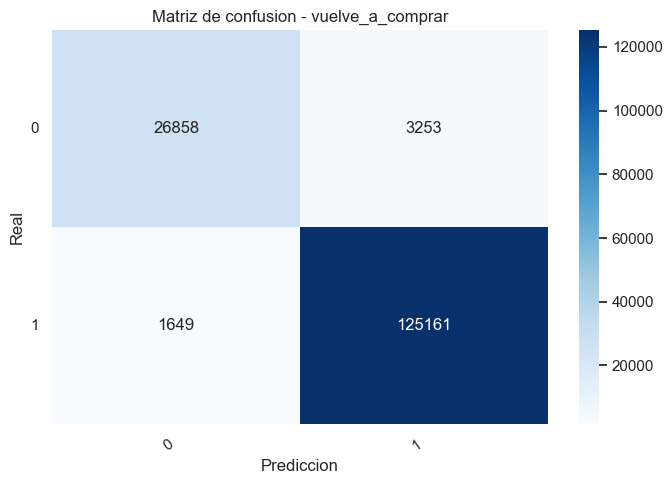

pred,0,1
real,,
0,26858,3253
1,1649,125161


In [36]:
recompra_df = df[["vuelve_a_comprar", "score_riesgo_0_100"]].dropna().copy()
recompra_df["real"] = recompra_df["vuelve_a_comprar"].round().clip(0, 1).astype(int)
recompra_df["pred"] = (recompra_df["score_riesgo_0_100"] < UMBRAL_RIESGO_RECOMPRA).astype(int)

labels_recompra = [0, 1]
metrics_recompra = classification_metrics(recompra_df["real"], recompra_df["pred"], labels_recompra, "vuelve_a_comprar")
display(metrics_recompra)
print(classification_report(recompra_df["real"], recompra_df["pred"], labels=labels_recompra, zero_division=0))
display(plot_confusion(recompra_df["real"], recompra_df["pred"], labels_recompra, "Matriz de confusion - vuelve_a_comprar"))

## Modelo potencial cliente secuencial

Filas evaluadas potencial: 12,685 | scope=test | min_history=2


,modelo,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,target_potencial_cliente,12685,0.735987,0.735398,0.724234,0.72676,0.733537,0.735987,0.731608


              precision    recall  f1-score   support

muy_negativo       0.92      0.89      0.90      2646
    negativo       0.74      0.83      0.78      3805
     estable       0.61      0.46      0.52      2375
    positivo       0.63      0.69      0.66      2660
muy_positivo       0.78      0.75      0.77      1199

    accuracy                           0.74     12685
   macro avg       0.74      0.72      0.73     12685
weighted avg       0.73      0.74      0.73     12685



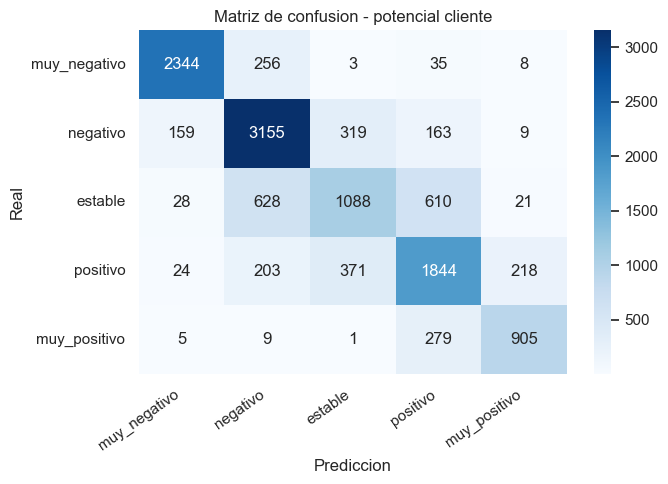

pred,muy_negativo,negativo,estable,positivo,muy_positivo
real,,,,,
muy_negativo,2344,256,3,35,8
negativo,159,3155,319,163,9
estable,28,628,1088,610,21
positivo,24,203,371,1844,218
muy_positivo,5,9,1,279,905


In [37]:
potencial_mask = df["sequence_length_potencial"] >= MIN_HISTORY_POTENCIAL
if EVAL_SCOPE == "test":
    potencial_mask &= df["is_test_potencial"]

potencial_df = df.loc[
    potencial_mask,
    ["target_potencial_cliente", "potencial_clase_predicha", "sequence_length_potencial"],
].dropna().copy()

potencial_df["real"] = pd.cut(
    potencial_df["target_potencial_cliente"],
    bins=POTENCIAL_BINS,
    labels=POTENCIAL_CLASS_NAMES,
    include_lowest=True,
).astype("string")
potencial_df["pred"] = potencial_df["potencial_clase_predicha"].astype("string")
potencial_df = potencial_df.dropna(subset=["real", "pred"])

print(f"Filas evaluadas potencial: {len(potencial_df):,} | scope={EVAL_SCOPE} | min_history={MIN_HISTORY_POTENCIAL}")
metrics_potencial = classification_metrics(potencial_df["real"], potencial_df["pred"], POTENCIAL_CLASS_NAMES, "target_potencial_cliente")
display(metrics_potencial)
print(classification_report(potencial_df["real"], potencial_df["pred"], labels=POTENCIAL_CLASS_NAMES, zero_division=0))
display(plot_confusion(potencial_df["real"], potencial_df["pred"], POTENCIAL_CLASS_NAMES, "Matriz de confusion - potencial cliente"))

## Modelo dias hasta proxima compra secuencial

Filas evaluadas dias: 10,701 | scope=test | min_history=2 | solo vuelve_a_comprar=1


,modelo,n,mae,rmse,r2,error_medio,error_abs_mediano
0,dias_hasta_proxima_compra,10701,28.612158,44.155683,0.810871,-9.204644,17.7


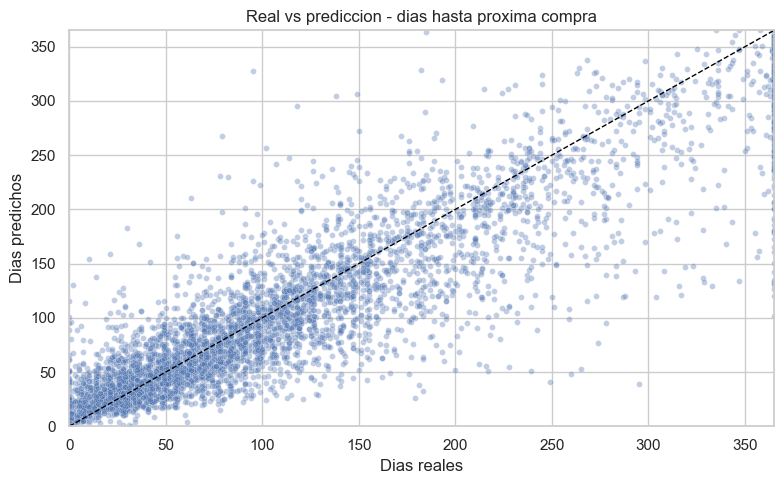

In [38]:
dias_mask = (df["vuelve_a_comprar"] == 1) & (df["sequence_length_dias"] >= MIN_HISTORY_DIAS)
if EVAL_SCOPE == "test":
    dias_mask &= df["is_test_dias"]

dias_df = df.loc[
    dias_mask,
    ["dias_hasta_proxima_compra", "prediccion_dias_hasta_proxima_compra", "prediccion_bucket_mes_modelo_dias", "sequence_length_dias"],
].dropna().copy()
dias_df["real_dias"] = dias_df["dias_hasta_proxima_compra"].astype(float).clip(lower=0, upper=365)
dias_df["pred_dias"] = dias_df["prediccion_dias_hasta_proxima_compra"].astype(float)

metrics_dias = pd.DataFrame([
    {
        "modelo": "dias_hasta_proxima_compra",
        "n": len(dias_df),
        "mae": mean_absolute_error(dias_df["real_dias"], dias_df["pred_dias"]),
        "rmse": root_mean_squared_error(dias_df["real_dias"], dias_df["pred_dias"]),
        "r2": r2_score(dias_df["real_dias"], dias_df["pred_dias"]),
        "error_medio": (dias_df["pred_dias"] - dias_df["real_dias"]).mean(),
        "error_abs_mediano": (dias_df["pred_dias"] - dias_df["real_dias"]).abs().median(),
    }
])
print(f"Filas evaluadas dias: {len(dias_df):,} | scope={EVAL_SCOPE} | min_history={MIN_HISTORY_DIAS} | solo vuelve_a_comprar=1")
display(metrics_dias)

sample = dias_df.sample(min(len(dias_df), 5000), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="real_dias", y="pred_dias", alpha=0.35, s=18)
limit = max(365, dias_df["pred_dias"].max())
plt.plot([0, 365], [0, 365], color="black", linestyle="--", linewidth=1)
plt.xlim(0, 365)
plt.ylim(0, limit)
plt.title("Real vs prediccion - dias hasta proxima compra")
plt.xlabel("Dias reales")
plt.ylabel("Dias predichos")
plt.tight_layout()
plt.show()

,modelo,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,dias_hasta_proxima_compra_buckets,10701,0.401271,0.374398,0.330041,0.299796,0.403675,0.401271,0.387708


              precision    recall  f1-score   support

      mes_00       0.62      0.71      0.66      1725
      mes_01       0.45      0.48      0.47      1842
      mes_02       0.37      0.50      0.43      1557
      mes_03       0.39      0.34      0.36      1367
      mes_04       0.35      0.30      0.32       954
      mes_05       0.35      0.26      0.30       665
      mes_06       0.35      0.24      0.29       576
      mes_07       0.33      0.26      0.29       450
      mes_08       0.47      0.19      0.27       308
      mes_09       0.35      0.14      0.20       232
      mes_10       0.72      0.07      0.13       187
      mes_11       0.10      0.80      0.18       156
      mes_12       0.00      0.00      0.00       682

    accuracy                           0.40     10701
   macro avg       0.37      0.33      0.30     10701
weighted avg       0.40      0.40      0.39     10701



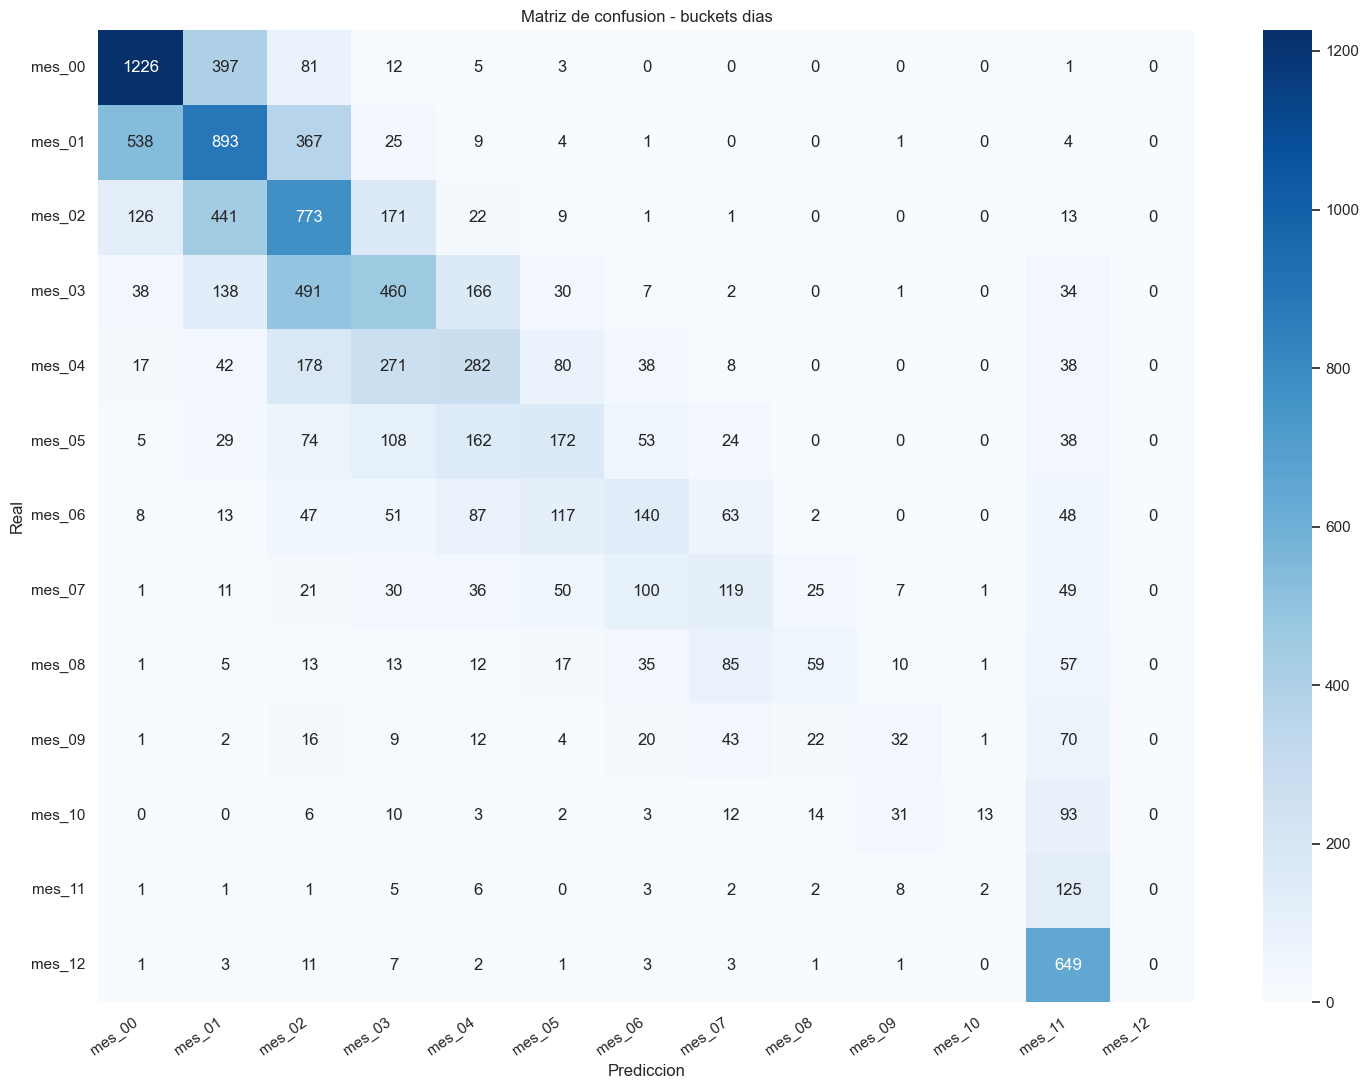

pred,mes_00,mes_01,mes_02,mes_03,mes_04,mes_05,mes_06,mes_07,mes_08,mes_09,mes_10,mes_11,mes_12
real,,,,,,,,,,,,,
mes_00,1226,397,81,12,5,3,0,0,0,0,0,1,0
mes_01,538,893,367,25,9,4,1,0,0,1,0,4,0
mes_02,126,441,773,171,22,9,1,1,0,0,0,13,0
mes_03,38,138,491,460,166,30,7,2,0,1,0,34,0
mes_04,17,42,178,271,282,80,38,8,0,0,0,38,0
mes_05,5,29,74,108,162,172,53,24,0,0,0,38,0
mes_06,8,13,47,51,87,117,140,63,2,0,0,48,0
mes_07,1,11,21,30,36,50,100,119,25,7,1,49,0
mes_08,1,5,13,13,12,17,35,85,59,10,1,57,0


In [39]:
dias_df["real_bucket"] = bucket_days(dias_df["real_dias"])
dias_df["pred_bucket"] = dias_df["prediccion_bucket_mes_modelo_dias"].astype("string")
dias_df = dias_df.dropna(subset=["real_bucket", "pred_bucket"])

bucket_labels = [label for label in DIAS_BUCKET_LABELS if dias_df["real_bucket"].eq(label).any() or dias_df["pred_bucket"].eq(label).any()]
metrics_dias_buckets = classification_metrics(dias_df["real_bucket"], dias_df["pred_bucket"], bucket_labels, "dias_hasta_proxima_compra_buckets")
display(metrics_dias_buckets)
print(classification_report(dias_df["real_bucket"], dias_df["pred_bucket"], labels=bucket_labels, zero_division=0))
display(plot_confusion(dias_df["real_bucket"], dias_df["pred_bucket"], bucket_labels, "Matriz de confusion - buckets dias"))

## Resumen global

In [40]:
resumen_clasificacion = pd.concat([metrics_recompra, metrics_potencial, metrics_dias_buckets], ignore_index=True)
display(resumen_clasificacion)
display(metrics_dias)

,modelo,n,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,vuelve_a_comprar,156921,0.968761,0.958411,0.939481,0.948584,0.968429,0.968761,0.968432
1,target_potencial_cliente,12685,0.735987,0.735398,0.724234,0.726760,0.733537,0.735987,0.731608
2,dias_hasta_proxima_compra_buckets,10701,0.401271,0.374398,0.330041,0.299796,0.403675,0.401271,0.387708


,modelo,n,mae,rmse,r2,error_medio,error_abs_mediano
0,dias_hasta_proxima_compra,10701,28.612158,44.155683,0.810871,-9.204644,17.7
